In [26]:
# ==========================================
# 1. Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import pickle

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC

from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [27]:
# ==========================================
# 2. Load Dataset
# ==========================================

data = pd.read_csv("heart.csv")

print("Dataset Loaded Successfully")

print("\nShape of Dataset:")
print(data.shape)

print("\nFirst 5 Rows")
print(data.head())

Dataset Loaded Successfully

Shape of Dataset:
(1025, 14)

First 5 Rows
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [28]:
# ==========================================
# 3. Rename Columns
# ==========================================

data.rename(columns={

    'age':'Age',
    'sex':'Gender',
    'cp':'ChestPainType',
    'trestbps':'RestingBp',
    'chol':'Cholesterol',
    'fbs':'FastingBS',
    'restecg':'RestingECG',
    'thalach':'MaxHR',
    'exang':'ExerciseAngina',
    'oldpeak':'ST_Depression',
    'slope':'ST_Slope',
    'ca':'MajorVessels',
    'thal':'Thalassemia',
    'target':'HeartDisease'

}, inplace=True)

print("Columns Renamed Successfully")

print(data.head())

Columns Renamed Successfully
   Age  Gender  ChestPainType  RestingBp  Cholesterol  FastingBS  RestingECG  \
0   52       1              0        125          212          0           1   
1   53       1              0        140          203          1           0   
2   70       1              0        145          174          0           1   
3   61       1              0        148          203          0           1   
4   62       0              0        138          294          1           1   

   MaxHR  ExerciseAngina  ST_Depression  ST_Slope  MajorVessels  Thalassemia  \
0    168               0            1.0         2             2            3   
1    155               1            3.1         0             0            3   
2    125               1            2.6         0             0            3   
3    161               0            0.0         2             1            3   
4    106               0            1.9         1             3            2   

   HeartD

In [29]:
# ==========================================
# 4. Dataset Information
# ==========================================

print("Shape of Dataset")
print(data.shape)

print("\nColumn Names")
print(data.columns)

print("\nDataset Information")
print(data.info())

print("\nMissing Values")
print(data.isnull().sum())

print("\nStatistical Summary")
print(data.describe())

Shape of Dataset
(1025, 14)

Column Names
Index(['Age', 'Gender', 'ChestPainType', 'RestingBp', 'Cholesterol',
       'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'ST_Depression',
       'ST_Slope', 'MajorVessels', 'Thalassemia', 'HeartDisease'],
      dtype='object')

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             1025 non-null   int64  
 1   Gender          1025 non-null   int64  
 2   ChestPainType   1025 non-null   int64  
 3   RestingBp       1025 non-null   int64  
 4   Cholesterol     1025 non-null   int64  
 5   FastingBS       1025 non-null   int64  
 6   RestingECG      1025 non-null   int64  
 7   MaxHR           1025 non-null   int64  
 8   ExerciseAngina  1025 non-null   int64  
 9   ST_Depression   1025 non-null   float64
 10  ST_Slope        1025 non-null   int64  
 11  Majo

In [30]:
# ==========================================
# 5. Remove Duplicate Rows
# ==========================================

print("Dataset Shape Before Removing Duplicates")

print(data.shape)

duplicates = data.duplicated().sum()

print("Duplicate Rows :", duplicates)

data = data.drop_duplicates()

print("Dataset Shape After Removing Duplicates")

print(data.shape)

Dataset Shape Before Removing Duplicates
(1025, 14)
Duplicate Rows : 723
Dataset Shape After Removing Duplicates
(302, 14)


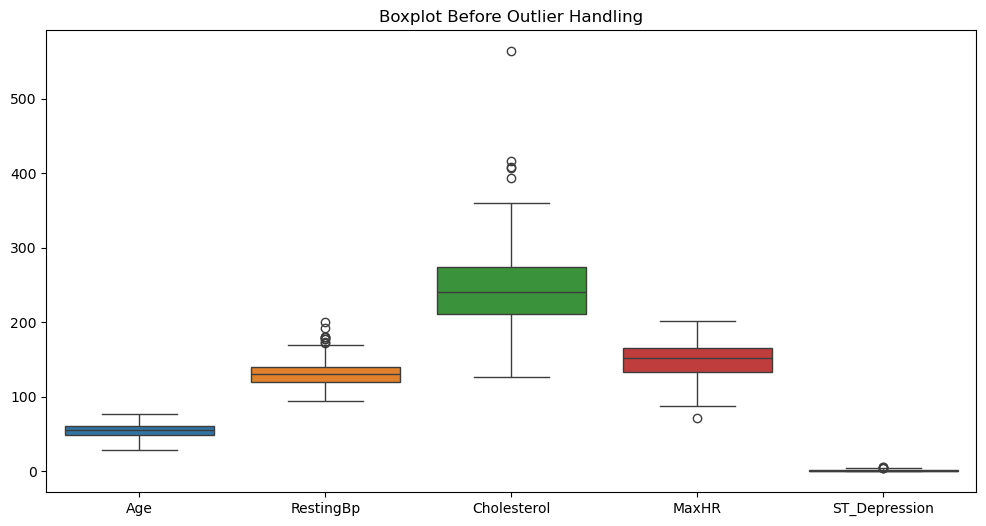

In [31]:
# ==========================================
# 6. Outlier Detection
# ==========================================

numerical_cols = [
    'Age',
    'RestingBp',
    'Cholesterol',
    'MaxHR',
    'ST_Depression'
]

plt.figure(figsize=(12,6))

sns.boxplot(data=data[numerical_cols])

plt.title("Boxplot Before Outlier Handling")

plt.show()

In [32]:
# ==========================================
# 7. Handle Outliers
# ==========================================

def cap_outliers(df, column):

    Q1 = df[column].quantile(0.25)

    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    df[column] = np.where(
        df[column] < lower,
        lower,
        np.where(df[column] > upper, upper, df[column])
    )


for col in numerical_cols:

    cap_outliers(data, col)

print("Outliers handled successfully.")

Outliers handled successfully.


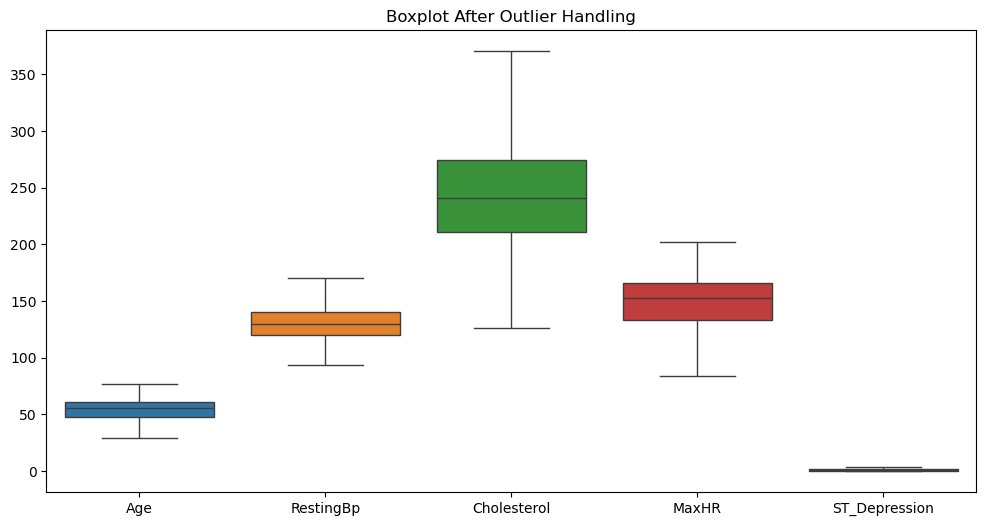

In [33]:
# ==========================================
# 8. Verify Outliers
# ==========================================

plt.figure(figsize=(12,6))

sns.boxplot(data=data[numerical_cols])

plt.title("Boxplot After Outlier Handling")

plt.show()

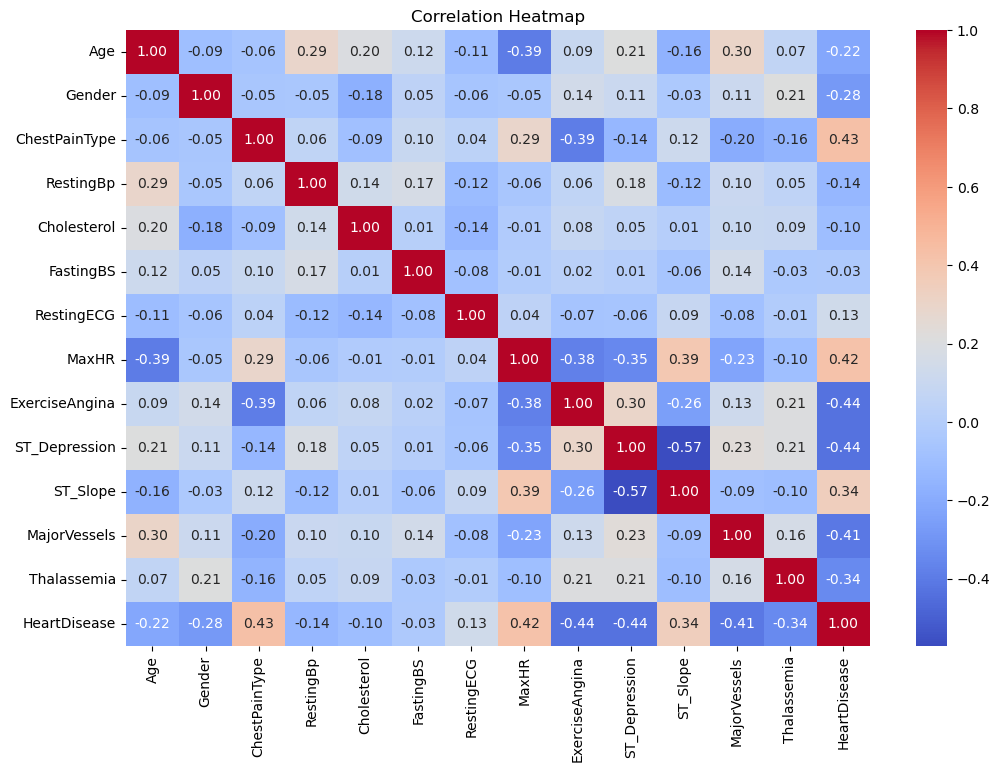

In [34]:
# ==========================================
# 9. Correlation Heatmap
# ==========================================

plt.figure(figsize=(12,8))

sns.heatmap(
    data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [35]:
# ==========================================
# 10. Separate Features and Target
# ==========================================

X = data.drop("HeartDisease", axis=1)

y = data["HeartDisease"]

print("Feature Shape :", X.shape)

print("Target Shape :", y.shape)

Feature Shape : (302, 13)
Target Shape : (302,)


In [36]:
# ==========================================
# 11. One-Hot Encoding
# ==========================================

categorical_cols = [
    'Gender',
    'ChestPainType',
    'FastingBS',
    'RestingECG',
    'ExerciseAngina',
    'ST_Slope',
    'MajorVessels',
    'Thalassemia'
]

X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

print("Shape After Encoding :", X.shape)

X.head()

Shape After Encoding : (302, 22)


,Age,RestingBp,Cholesterol,MaxHR,ST_Depression,Gender_1,ChestPainType_1,ChestPainType_2,ChestPainType_3,FastingBS_1,...,ExerciseAngina_1,ST_Slope_1,ST_Slope_2,MajorVessels_1,MajorVessels_2,MajorVessels_3,MajorVessels_4,Thalassemia_1,Thalassemia_2,Thalassemia_3
0,52.0,125.0,212.0,168.0,1.0,True,False,False,False,False,...,False,False,True,False,True,False,False,False,False,True
1,53.0,140.0,203.0,155.0,3.1,True,False,False,False,True,...,True,False,False,False,False,False,False,False,False,True
2,70.0,145.0,174.0,125.0,2.6,True,False,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,61.0,148.0,203.0,161.0,0.0,True,False,False,False,False,...,False,False,True,True,False,False,False,False,False,True
4,62.0,138.0,294.0,106.0,1.9,False,False,False,False,True,...,False,True,False,False,False,True,False,False,True,False


In [37]:
# ==========================================
# 12. Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape :", X_test.shape)

Training Data Shape : (241, 22)
Testing Data Shape : (61, 22)


In [38]:
# ==========================================
# 13. Standard Scaling
# ==========================================

numerical_cols = [
    'Age',
    'RestingBp',
    'Cholesterol',
    'MaxHR',
    'ST_Depression'
]

scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(
    X_train[numerical_cols]
)

X_test[numerical_cols] = scaler.transform(
    X_test[numerical_cols]
)

print("Scaling Completed Successfully")

Scaling Completed Successfully


In [39]:
# ==========================================
# 14. Save Feature Names
# ==========================================

feature_names = X_train.columns.tolist()

with open("feature_names.pkl","wb") as file:

    pickle.dump(feature_names,file)

print("feature_names.pkl saved successfully")

feature_names.pkl saved successfully


In [40]:
# ==========================================
# 15. Logistic Regression
# ==========================================

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train,y_train)

y_pred_log = log_model.predict(X_test)

acc_log = accuracy_score(y_test,y_pred_log)

print("Logistic Regression Accuracy")

print(round(acc_log*100,2),"%")

print(classification_report(y_test,y_pred_log))

Logistic Regression Accuracy
85.25 %
              precision    recall  f1-score   support

           0       0.83      0.86      0.84        28
           1       0.88      0.85      0.86        33

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [41]:
# ==========================================
# 16. KNN Classifier
# ==========================================

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train,y_train)

y_pred_knn = knn_model.predict(X_test)

acc_knn = accuracy_score(y_test,y_pred_knn)

print("KNN Accuracy")

print(round(acc_knn*100,2),"%")

print(classification_report(y_test,y_pred_knn))

KNN Accuracy
80.33 %
              precision    recall  f1-score   support

           0       0.75      0.86      0.80        28
           1       0.86      0.76      0.81        33

    accuracy                           0.80        61
   macro avg       0.81      0.81      0.80        61
weighted avg       0.81      0.80      0.80        61



In [42]:
# ==========================================
# 17. Decision Tree
# ==========================================

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train,y_train)

y_pred_dt = dt_model.predict(X_test)

acc_dt = accuracy_score(y_test,y_pred_dt)

print("Decision Tree Accuracy")

print(round(acc_dt*100,2),"%")

print(classification_report(y_test,y_pred_dt))

Decision Tree Accuracy
65.57 %
              precision    recall  f1-score   support

           0       0.63      0.61      0.62        28
           1       0.68      0.70      0.69        33

    accuracy                           0.66        61
   macro avg       0.65      0.65      0.65        61
weighted avg       0.65      0.66      0.66        61



Random Forest Accuracy
80.33 %
              precision    recall  f1-score   support

           0       0.79      0.79      0.79        28
           1       0.82      0.82      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



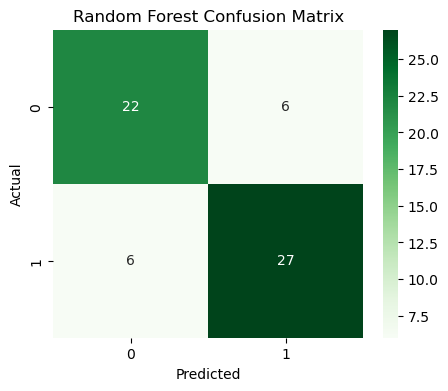

In [43]:
# ==========================================
# 18. Random Forest Classifier
# ==========================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy")

print(round(acc_rf * 100, 2), "%")

print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [44]:
# ==========================================
# 19. Support Vector Machine
# ==========================================

svm_model = SVC(
    probability=True,
    random_state=42
)

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy")

print(round(acc_svm * 100,2), "%")

print(classification_report(y_test, y_pred_svm))

SVM Accuracy
81.97 %
              precision    recall  f1-score   support

           0       0.79      0.82      0.81        28
           1       0.84      0.82      0.83        33

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



In [45]:
# ==========================================
# 20. Gaussian Naive Bayes
# ==========================================

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

acc_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy")

print(round(acc_nb * 100,2), "%")

print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy
83.61 %
              precision    recall  f1-score   support

           0       0.85      0.79      0.81        28
           1       0.83      0.88      0.85        33

    accuracy                           0.84        61
   macro avg       0.84      0.83      0.83        61
weighted avg       0.84      0.84      0.84        61



                 Model  Accuracy
0  Logistic Regression  0.852459
5          Naive Bayes  0.836066
4                  SVM  0.819672
1                  KNN  0.803279
3        Random Forest  0.803279
2        Decision Tree  0.655738


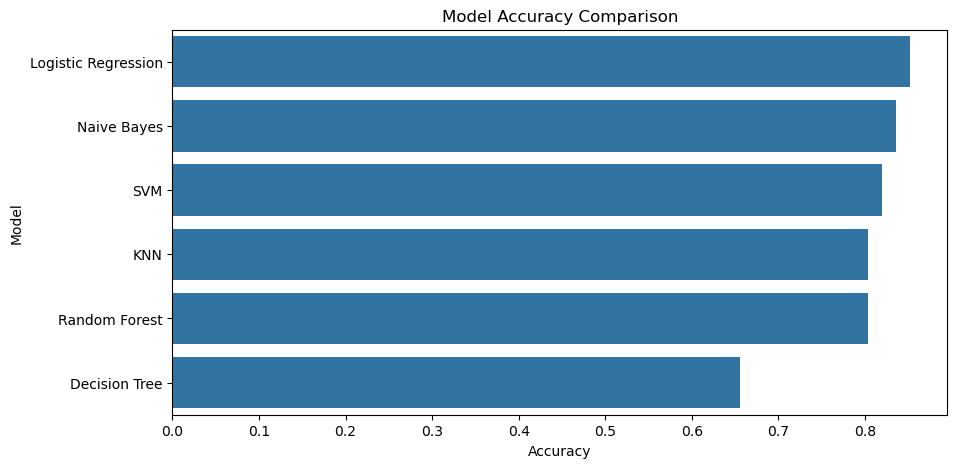

In [46]:
# ==========================================
# 21. Model Comparison
# ==========================================

results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "Naive Bayes"
    ],

    "Accuracy":[
        acc_log,
        acc_knn,
        acc_dt,
        acc_rf,
        acc_svm,
        acc_nb
    ]

})

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

print(results)

plt.figure(figsize=(10,5))

sns.barplot(
    x="Accuracy",
    y="Model",
    data=results
)

plt.title("Model Accuracy Comparison")

plt.show()

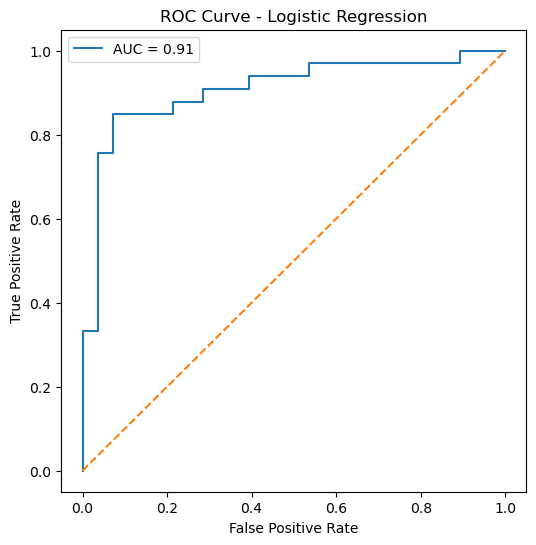

In [52]:
# ==========================================
# # ==========================================
# 22. ROC Curve - Logistic Regression
# ==========================================

y_prob = log_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.2f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

             Feature  Importance
16    MajorVessels_2    2.025414
15    MajorVessels_1    1.479230
7    ChestPainType_2    1.476585
8    ChestPainType_3    1.433784
5           Gender_1    1.326428
17    MajorVessels_3    1.021708
12  ExerciseAngina_1    0.835348
3              MaxHR    0.771140
21     Thalassemia_3    0.752762
6    ChestPainType_1    0.610089
20     Thalassemia_2    0.537951
19     Thalassemia_1    0.481681
13        ST_Slope_1    0.401891
18    MajorVessels_4    0.379057
14        ST_Slope_2    0.354197


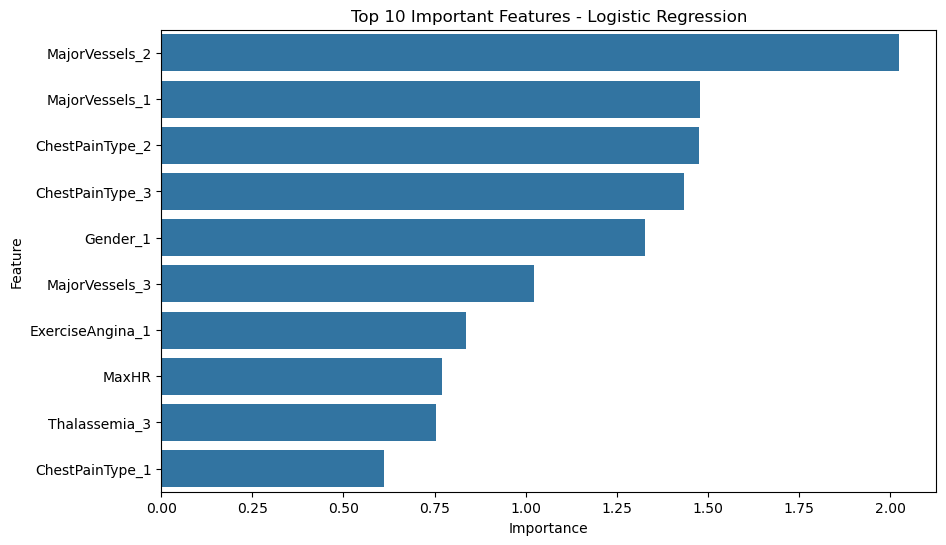

In [53]:
# ==========================================
# 23. Feature Importance - Logistic Regression
# ==========================================

importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": abs(log_model.coef_[0])

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(15))


plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features - Logistic Regression")

plt.show()

In [54]:
# ==========================================
# 24. Hyperparameter Tuning - Logistic Regression
# ==========================================

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression


param_grid = {

    "C": [0.01, 0.1, 1, 10, 100],

    "solver": ["liblinear", "lbfgs"],

    "max_iter": [100, 200, 500]

}


grid = GridSearchCV(

    LogisticRegression(random_state=42),

    param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)


grid.fit(X_train, y_train)


best_log_model = grid.best_estimator_


print("Best Parameters")

print(grid.best_params_)


print("Best Accuracy")

print(grid.best_score_)

Best Parameters
{'C': 1, 'max_iter': 100, 'solver': 'liblinear'}
Best Accuracy
0.8256802721088435


In [55]:
# ==========================================
# 25. Save Final Model
# ==========================================

import pickle


with open("heart-disease-model.pkl","wb") as file:

    pickle.dump((best_log_model, scaler), file)


print("heart-disease-model.pkl saved successfully")


with open("feature_names.pkl","wb") as file:

    pickle.dump(X_train.columns.tolist(), file)


print("feature_names.pkl saved successfully")

heart-disease-model.pkl saved successfully
feature_names.pkl saved successfully
